In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 세부 항목별 매출 현황 및 예측 (단위: 조 원)

In [ ]:
combined_df_pivot = pd.concat([df_pivot, predictions_df])
display(combined_df_pivot)

산업별(1)         물리보안                   정보보안                       
산업별(2) 물리보안 제품(솔루션) 물리보안관련 서비스 정보보안 관련 서비스   정보보안 기타 정보보안 제품(솔루션)
2022       7.242309   3.320918    1.585586  0.023980     4.005729
2023       7.194223   3.491345    1.749086  0.144404     4.251988
2024       7.825844   3.644233    2.013609  0.055291     5.055506
2025       8.004327   3.808814    2.210783  0.105869     5.487518
2026       8.296094   3.970471    2.424795  0.121525     6.012406

### 전체 산업 총계 매출 현황 및 예측 (단위: 조 원)

In [ ]:
combined_total_series = pd.concat([total_series, total_predictions_series])
display(combined_total_series.to_frame(name='총계 매출액'))

,총계 매출액
2022,16.178521
2023,16.831047
2024,18.594484
2025,19.617314
2026,20.825295


In [ ]:
!apt-get -qq -y install fonts-nanum
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import matplotlib.ticker as mticker

# Install and set Nanum font
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# Load the Excel file with the correct path
file_path = '/content/drive/MyDrive/구글코랩/정보보호산업_매출현황_20260324234358.xlsx'
df = pd.read_excel(file_path)

print("Original DataFrame head:")
display(df.head())

Original DataFrame head:


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,산업별(1),산업별(2),산업별(3),2022,2023,2024
0,총계,소계,소계,16178521,16831047,18594484
1,정보보안,소계,소계,5615295,6145479,7124407
2,NaN,정보보안 제품(솔루션),소계,4005729,4251988,5055506
3,NaN,NaN,네트워크보안 솔루션,1508712,1803057,1856248
4,NaN,NaN,엔드포인트보안 솔루션,554235,568154,768013


데이터를 로드하고 컬럼 구조를 확인했습니다. 이제 요청하신 대로 '산업별(1)' 컬럼을 기준으로 데이터를 필터링하고 시각화에 필요한 형태로 가공하겠습니다.

In [ ]:
# Filter the data based on '산업별(1)' column and its subcategories
# For '총계'
filter_total = df['산업별(1)'] == '총계'
# For '정보보안 소계' (assuming it's a row where '산업별(1)' is '정보보안' and '산업별(2)' is '소계')
filter_info_security_subtotal = (df['산업별(1)'] == '정보보안') & (df['산업별(2)'] == '소계')
# For '물리보안 소계' (assuming it's a row where '산업별(1)' is '물리보안' and '산업별(2)'] is '소계')
filter_physical_security_subtotal = (df['산업별(1)'] == '물리보안') & (df['산업별(2)'] == '소계')

# Combine the filters
filtered_df = df[filter_total | filter_info_security_subtotal | filter_physical_security_subtotal].copy()

# Set '산업별(1)' as index. This will make '총계', '정보보안', '물리보안' the index labels.
filtered_df = filtered_df.set_index('산업별(1)')

# Extract year columns (assuming they are numerical and represent years)
year_columns = [col for col in filtered_df.columns if str(col).isdigit()]

# Melt the DataFrame to long format for easier plotting
# Transpose first, then reset index to make '연도' a regular column
df_melted = filtered_df[year_columns].T.reset_index()
df_melted = df_melted.rename(columns={'index': '연도'})

# Ensure '연도' is integer type and sort it
df_melted['연도'] = df_melted['연도'].astype(int)
df_melted = df_melted.sort_values(by='연도')

print("Filtered and Transformed DataFrame head:")
display(df_melted.head())
print("Filtered and Transformed DataFrame columns:")
display(df_melted.columns)

Filtered and Transformed DataFrame head:


산업별(1),연도,총계,정보보안,물리보안
0,2022,16178521,5615295,10563226
1,2023,16831047,6145479,10685568
2,2024,18594484,7124407,11470077


Filtered and Transformed DataFrame columns:


Index(['연도', '총계', '정보보안', '물리보안'], dtype='object', name='산업별(1)')

필터링 및 데이터 가공이 완료되었습니다. 이제 시각화 요청사항에 따라 그래프를 생성하겠습니다.

### 산업별(2) 세부 제품/서비스별 매출 현황 시각화
'산업별(1)'의 총계와 '산업별(2)'의 주요 제품 및 서비스 소계 항목들을 필터링하여 비교합니다.

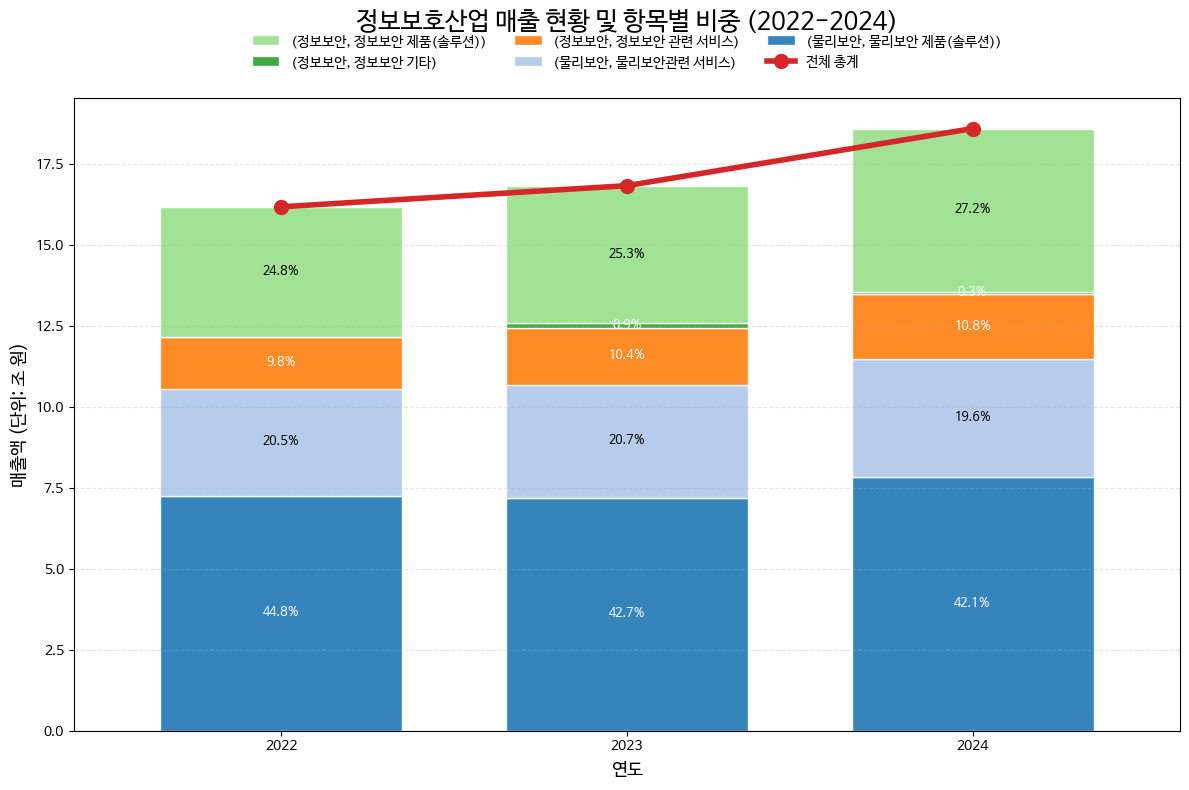

In [ ]:
import numpy as np

# 1. 데이터 전처리
df_final = df.copy()
df_final['산업별(1)'] = df_final['산업별(1)'].ffill()

# '산업별(3)'이 '소계'인 행 추출
df_sub = df_final[df_final['산업별(3)'].fillna('').str.contains('소계')].copy()

# 막대용: 산업별(2)가 '소계'가 아닌 항목들 추출
df_items = df_sub[~df_sub['산업별(2)'].fillna('').str.contains('^소계$')].copy()

# 라인용: 산업별(1)이 '총계'인 행 추출
df_total_raw = df[df['산업별(1)'] == '총계'].copy()

# 연도 컬럼 추출 및 단위 변환 (백만 원 -> 조 원)
year_cols = [col for col in df_items.columns if str(col).isdigit()]
for col in year_cols:
    df_items[col] = pd.to_numeric(df_items[col], errors='coerce').fillna(0) / 1000000
    df_total_raw[col] = pd.to_numeric(df_total_raw[col], errors='coerce').fillna(0) / 1000000

# 시각화용 피벗
df_pivot = df_items.pivot_table(index=None, columns=['산업별(1)', '산업별(2)'], values=year_cols, aggfunc='sum').T
df_pivot.columns = year_cols
df_pivot = df_pivot.T # 행: 연도, 열: 세부항목

# 총계 데이터 정리
total_series = df_total_raw.set_index('산업별(1)')[year_cols].T.iloc[:, 0]

# 2. 시각화
fig, ax = plt.subplots(figsize=(12, 8))

# 색상 설정 (산업별 구분)
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c', '#98df8a']

# 누적 막대 그래프
df_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.7, color=colors, edgecolor='white', alpha=0.9)

# 총계 라인 그래프 (Red, 두껍게)
ax.plot(range(len(df_pivot)), total_series.values, color='#d62728', marker='o',
        markersize=10, linewidth=4, label='전체 총계', zorder=5)

# 막대 내부 비중(%) 표시 및 색상 대비 처리
for i, (idx, row) in enumerate(df_pivot.iterrows()):
    cumulative_height = 0
    total_val = row.sum()
    for j, val in enumerate(row):
        if val > 0.05: # 너무 작은 값은 텍스트 생략
            percentage = (val / total_val) * 100
            # 어두운 색상 인덱스일 경우 흰색으로 표시
            text_color = 'white' if j in [0, 2, 3] else 'black'
            ax.text(i, cumulative_height + val/2, f'{percentage:.1f}%',
                    ha='center', va='center', color=text_color, fontweight='bold', fontsize=9)
        cumulative_height += val

# 스타일링 (제목 여백 확대)
ax.set_title('정보보호산업 매출 현황 및 항목별 비중 (2022-2024)', fontproperties=font_prop, fontsize=18, pad=50)
ax.set_ylabel('매출액 (단위: 조 원)', fontproperties=font_prop, fontsize=13)
ax.set_xlabel('연도', fontproperties=font_prop, fontsize=13)

# Y축 포맷 (소수점 1자리)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# 범례 설정 (위치 조정하여 겹침 방지)
handles, labels = ax.get_legend_handles_labels()
ax.legend(list(reversed(handles)), list(reversed(labels)), prop=font_prop,
          loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

plt.xticks(range(len(df_pivot)), df_pivot.index, rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 요약 통계량 계산 (피벗 테이블 기준)
print("세부 항목별 매출 요약 통계 (2022-2024, 단위: 조 원):")
display(df_pivot.describe())

# 산업 전체 총계에 대한 통계
print("\n전체 산업 총계 요약 통계 (2022-2024, 단위: 조 원):")
display(total_series.describe())

세부 항목별 매출 요약 통계 (2022-2024, 단위: 조 원):


산업별(1)         물리보안                   정보보안                       
산업별(2) 물리보안 제품(솔루션) 물리보안관련 서비스 정보보안 관련 서비스   정보보안 기타 정보보안 제품(솔루션)
count      3.000000   3.000000    3.000000  3.000000     3.000000
mean       7.420792   3.485499    1.782760  0.074558     4.437741
std        0.351608   0.161737    0.215989  0.062481     0.548986
min        7.194223   3.320918    1.585586  0.023980     4.005729
25%        7.218266   3.406131    1.667336  0.039636     4.128858
50%        7.242309   3.491345    1.749086  0.055291     4.251988
75%        7.534076   3.567789    1.881347  0.099848     4.653747
max        7.825844   3.644233    2.013609  0.144404     5.055506


전체 산업 총계 요약 통계 (2022-2024, 단위: 조 원):


,매출액
count,3.000000
mean,17.201351
std,1.249825
min,16.178521
25%,16.504784
50%,16.831047
75%,17.712766
max,18.594484


Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


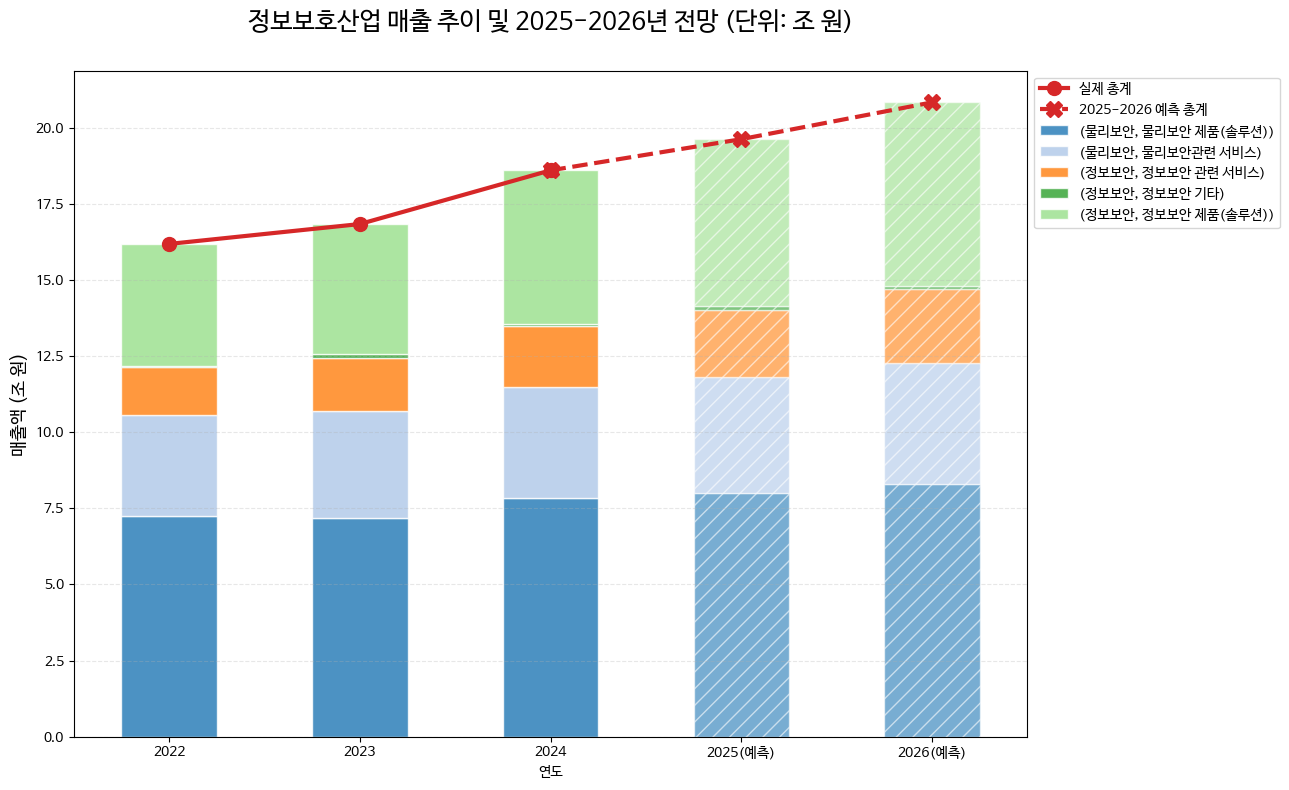

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
import pandas as pd
import os

# 0. 폰트 설정 및 데이터 로드
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if not os.path.exists(font_path):
    !apt-get -qq -y install fonts-nanum

fe = fm.FontEntry(fname=font_path, name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False
font_prop = fm.FontProperties(fname=font_path)

file_path = '/content/drive/MyDrive/구글코랩/정보보호산업_매출현황_20260324234358.xlsx'
df = pd.read_excel(file_path)

# 1. 데이터 가공
df_final = df.copy()
df_final['산업별(1)'] = df_final['산업별(1)'].ffill()
df_sub = df_final[df_final['산업별(3)'].fillna('').str.contains('소계')].copy()
df_items = df_sub[~df_sub['산업별(2)'].fillna('').str.contains('^소계$')].copy()
df_total_raw = df[df['산업별(1)'] == '총계'].copy()

year_cols = [col for col in df_items.columns if str(col).isdigit()]
for col in year_cols:
    df_items[col] = pd.to_numeric(df_items[col], errors='coerce').fillna(0) / 1000000
    df_total_raw[col] = pd.to_numeric(df_total_raw[col], errors='coerce').fillna(0) / 1000000

df_pivot = df_items.melt(id_vars=['산업별(1)', '산업별(2)'], value_vars=year_cols, var_name='연도', value_name='매출액')
df_pivot['연도'] = df_pivot['연도'].astype(int)
df_pivot = df_pivot.pivot_table(index='연도', columns=['산업별(1)', '산업별(2)'], values='매출액', aggfunc='sum')

total_series = df_total_raw.melt(id_vars=['산업별(1)'], value_vars=year_cols, var_name='연도', value_name='매출액')
total_series['연도'] = total_series['연도'].astype(int)
total_series = total_series.set_index('연도')['매출액']

# 2. 2025년 및 2026년 예측
years_train = df_pivot.index.values.reshape(-1, 1) # 2022, 2023, 2024
future_years_predict = np.array([[2025], [2026]]) # Predict for 2025, 2026

# Predict for each sub-category
predictions_df = pd.DataFrame(index=future_years_predict.flatten(), columns=df_pivot.columns)
for col in df_pivot.columns:
    model = LinearRegression()
    model.fit(years_train, df_pivot[col])
    predicted_values = model.predict(future_years_predict)
    predictions_df[col] = [max(0, val) for val in predicted_values] # Ensure no negative predictions

# Predict for total
model_total = LinearRegression()
model_total.fit(years_train, total_series.values)
total_predictions = model_total.predict(future_years_predict)
total_predictions_series = pd.Series([max(0, val) for val in total_predictions], index=future_years_predict.flatten())

# 3. 시각화
fig, ax = plt.subplots(figsize=(13, 8))
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c', '#98df8a']
bar_width = 0.5

# Plot actual data (2022-2024) as stacked bars
df_pivot.plot(kind='bar', stacked=True, ax=ax, width=bar_width, color=colors, edgecolor='white', alpha=0.8)

# Plot predicted data (2025, 2026) with hatch to distinguish
predicted_years_x_positions = [3, 4] # Corresponds to 2025, 2026 on the x-axis
for year_idx, year in enumerate(future_years_predict.flatten()):
    bottom_val = 0
    for i, col in enumerate(predictions_df.columns):
        val = predictions_df.loc[year, col]
        ax.bar(predicted_years_x_positions[year_idx], val, bottom=bottom_val, color=colors[i], edgecolor='white', alpha=0.6, width=bar_width, hatch='//')
        bottom_val += val

# Combine actual and predicted total series for line plot
total_combined_series = pd.concat([total_series, total_predictions_series])
total_combined_x = np.arange(len(total_combined_series))

# Plot actual total line
ax.plot(total_combined_x[:len(total_series)], total_series.values, color='#d62728', marker='o', markersize=10, linewidth=3, label='실제 총계')

# Plot predicted total line with dashed style and 'X' markers
ax.plot(total_combined_x[len(total_series)-1:], total_combined_series.iloc[len(total_series)-1:].values,
        color='#d62728', marker='X', markersize=12, linewidth=3, linestyle='--', label='2025-2026 예측 총계')

ax.set_title('정보보호산업 매출 추이 및 2025-2026년 전망 (단위: 조 원)', fontproperties=font_prop, fontsize=18, pad=30)
ax.set_ylabel('매출액 (조 원)', fontproperties=font_prop, fontsize=13)
plt.xticks([0, 1, 2, 3, 4], ['2022', '2023', '2024', '2025(예측)', '2026(예측)'], rotation=0, fontproperties=font_prop)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# X축 범위 조정하여 모든 연도 막대가 잘리지 않게 함
ax.set_xlim(-0.5, 4.5)

handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), prop=font_prop, loc='upper left', bbox_to_anchor=(1, 1))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 데이터 요약 통계 정보
시각화에 사용된 세부 항목별 매출 데이터(조 원 단위)의 통계적 특성을 요약합니다.

In [ ]:
# 요약 통계량 계산 (피벗 테이블 기준)
print("세부 항목별 매출 요약 통계 (단위: 조 원):")
display(df_pivot.describe())

# 산업 전체 총계에 대한 통계
print("\n전체 산업 총계 요약 통계 (단위: 조 원):")
display(total_series.describe())

세부 항목별 매출 요약 통계 (단위: 조 원):


산업별(1)         물리보안                   정보보안                       
산업별(2) 물리보안 제품(솔루션) 물리보안관련 서비스 정보보안 관련 서비스   정보보안 기타 정보보안 제품(솔루션)
count      3.000000   3.000000    3.000000  3.000000     3.000000
mean       7.420792   3.485499    1.782760  0.074558     4.437741
std        0.351608   0.161737    0.215989  0.062481     0.548986
min        7.194223   3.320918    1.585586  0.023980     4.005729
25%        7.218266   3.406131    1.667336  0.039636     4.128858
50%        7.242309   3.491345    1.749086  0.055291     4.251988
75%        7.534076   3.567789    1.881347  0.099848     4.653747
max        7.825844   3.644233    2.013609  0.144404     5.055506


전체 산업 총계 요약 통계 (단위: 조 원):


,총계
count,3.000000
mean,17.201351
std,1.249825
min,16.178521
25%,16.504784
50%,16.831047
75%,17.712766
max,18.594484
